<a href="https://colab.research.google.com/github/Amna-Zeyaan/NorthStar-Analytics/blob/main/NorthStar_Python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
customers = pd.read_csv("customers.csv")
drivers = pd.read_csv("drivers.csv")
vehicles = pd.read_csv("vehicles.csv")
orders = pd.read_csv("orders.csv")
deliveries = pd.read_csv("deliveries.csv")
complaints = pd.read_csv("complaints.csv")
incidents = pd.read_csv("incidents.csv")
hubs = pd.read_csv("hubs.csv")
app_events = pd.read_csv("app_events.csv")

In [9]:
print(customers.shape)
print(deliveries.shape)
print(complaints.shape)

(650, 9)
(950, 13)
(320, 10)


In [10]:
customers.head()

,customer_id,age,home_zone,customer_type,signup_date,loyalty_score,app_engagement_score,preferred_channel,account_status
0,C0001,26,North,SME,2024-11-27 04:25:00,44.9,69.2,App,Active
1,C0002,61,AIRPORT,Consumer,2025-10-28 01:04:00,55.4,66.6,App,Active
2,C0003,66,East,Consumer,2025-07-02 03:23:00,75.9,33.8,NaN,Active
3,C0004,75,CENTRAL,Consumer,2025-08-19 01:58:00,32.5,33.0,App,Active
4,C0005,26,Riverside,Consumer,2025-06-03 06:02:00,55.9,100.0,Web,Active


In [11]:
print (customers .isnull().sum())
print (drivers .isnull() .sum())
print (vehicles .isnull().sum())
print (orders .isnull().sum())
print (deliveries .isnull().sum())
print (drivers.isnull().sum())
print (complaints .isnull().sum())
print (incidents .isnull().sum())
print (hubs .isnull().sum())
print (app_events .isnull().sum())

customer_id              0
age                      0
home_zone                0
customer_type            0
signup_date              0
loyalty_score           20
app_engagement_score     0
preferred_channel       13
account_status           0
dtype: int64
driver_id           0
base_zone           0
employment_type     0
years_experience    0
training_score      7
driver_rating       0
shift_preference    0
active_flag         0
dtype: int64
vehicle_id            0
vehicle_type          0
assigned_zone         0
commission_date       0
battery_health_pct    4
odometer_km           0
maintenance_status    0
telematics_version    0
dtype: int64
order_id                  0
customer_id               0
service_type              0
order_created_at          0
promised_window_hours     0
pickup_zone               0
dropoff_zone              0
priority_level            0
order_value               0
booking_channel          25
special_handling_flag     0
dtype: int64
delivery_id                  

In [3]:
# Fill loyalty_score with average
customers["loyalty_score"].fillna(customers["loyalty_score"].mean(), inplace=True)

# Fill preferred_channel with most common value
customers["preferred_channel"].fillna(customers["preferred_channel"].mode()[0], inplace=True)

# Fill compensation_amount with average
complaints["compensation_amount"].fillna(complaints["compensation_amount"].mean(), inplace=True)

/tmp/ipykernel_13991/704331456.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  customers["loyalty_score"].fillna(customers["loyalty_score"].mean(), inplace=True)
/tmp/ipykernel_13991/704331456.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].

In [4]:
drivers ["training_score"].fillna(drivers ["training_score"].mean(), inplace=True)
vehicles ["battery_health_pct"]. fillna(vehicles ["battery_health_pct"].mean(), inplace= True)
orders["booking_channel"].fillna(orders["booking_channel"].mode()[0], inplace=True)
deliveries["customer_rating_post_delivery"].fillna(deliveries["customer_rating_post_delivery"].mean(), inplace=True)
incidents ["resolved_hours"].fillna (incidents ["resolved_hours"].mean(), inplace= True)


/tmp/ipykernel_13991/665159067.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  drivers ["training_score"].fillna(drivers ["training_score"].mean(), inplace=True)
/tmp/ipykernel_13991/665159067.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].

In [14]:
print(customers["home_zone"].unique())
print(deliveries["delivery_status"].unique())
print(orders["pickup_zone"].unique())
print(orders["dropoff_zone"].unique())
print(vehicles["assigned_zone"].unique())
print(app_events["zone_context"].unique())

['North' 'AIRPORT' 'East' 'CENTRAL' 'Riverside' 'WEST' 'north' 'South'
 'West' 'Ctr' 'Airport' 'EAST' 'SOUTH' 'RiverSide' 'NORTH' 'Central']
['Failed' 'OnTime' 'Delayed']
['Airport' 'North' 'West' 'RiverSide' 'Riverside' 'CENTRAL' 'NORTH'
 'South' 'WEST' 'East' 'Ctr' 'SOUTH' 'Central' 'AIRPORT' 'north' 'EAST']
['South' 'AIRPORT' 'North' 'SOUTH' 'East' 'Airport' 'Riverside' 'north'
 'Central' 'Ctr' 'CENTRAL' 'NORTH' 'RiverSide' 'West' 'EAST' 'WEST']
['North' 'AIRPORT' 'north' 'RiverSide' 'West' 'Central' 'South' 'NORTH'
 'Riverside' 'SOUTH' 'WEST' 'Airport' 'CENTRAL' 'EAST' 'East' 'Ctr']
['north' 'SOUTH' 'Airport' 'CENTRAL' 'West' 'South' 'Ctr' 'North' 'WEST'
 'AIRPORT' 'RiverSide' 'NORTH' 'EAST' 'Riverside' 'East' 'Central']


In [5]:
customers["home_zone"] = customers["home_zone"].str.strip().str.title()
orders["pickup_zone"] = orders["pickup_zone"].str.strip().str.title()
orders["dropoff_zone"] = orders["dropoff_zone"].str.strip().str.title()
deliveries["delivery_status"] = deliveries["delivery_status"].str.strip().str.title()
vehicles["assigned_zone"] = vehicles ["assigned_zone"].str.strip().str.title()
app_events["zone_context"]= app_events["zone_context"].str.strip().str.title()

In [6]:
customers["home_zone"] = customers["home_zone"].replace("Ctr", "Central")
orders["pickup_zone"] = orders["pickup_zone"].replace("Ctr", "Central")
orders["dropoff_zone"] = orders["dropoff_zone"].replace("Ctr", "Central")
deliveries["delivery_status"] = deliveries["delivery_status"].replace("Ctr", "Central")
vehicles["assigned_zone"] = vehicles ["assigned_zone"].replace("Ctr", "Central")
app_events["zone_context"]= app_events["zone_context"].replace("Ctr", "Central")

In [17]:
print(customers["home_zone"].unique())

['North' 'Airport' 'East' 'Central' 'Riverside' 'West' 'South']


In [18]:
print(vehicles["assigned_zone"].unique())
print(app_events["zone_context"].unique())

['North' 'Airport' 'Riverside' 'West' 'Central' 'South' 'East']
['North' 'South' 'Airport' 'Central' 'West' 'Riverside' 'East']


In [19]:
#merging deliveries and orders together to get info about the deliveries and pickup zones
zone_performance = deliveries.merge(orders, on="order_id")

print(zone_performance.shape)

(950, 23)


In [21]:
#Group it by pickup_zone, Select the delivery_status column ,Count each status value
#Flip it into a readable table
delivery_by_zone = zone_performance.groupby("pickup_zone")["delivery_status"].value_counts().unstack()

print(delivery_by_zone)

delivery_status  Delayed  Failed  Ontime
pickup_zone                             
Airport               31      12      70
Central               51      33      90
East                  31      19     106
North                 21      22      92
Riverside             25      18      76
South                 22      14     103
West                  21      14      79


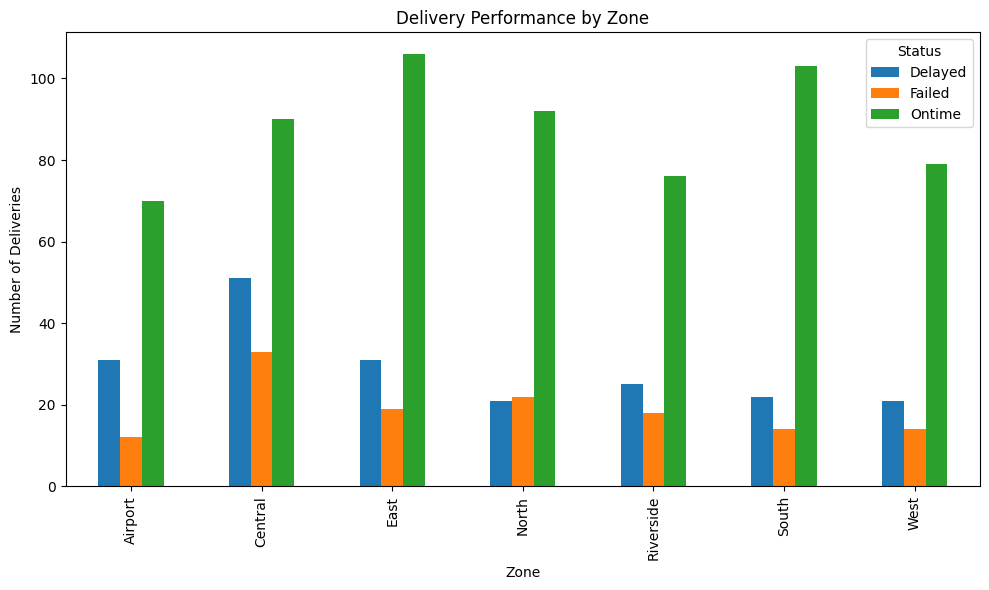

In [22]:
delivery_by_zone.plot(kind="bar", figsize=(10,6))
plt.title("Delivery Performance by Zone")
plt.xlabel("Zone")
plt.ylabel("Number of Deliveries")
plt.legend(title="Status")
plt.tight_layout()
plt.show()

In [23]:
driver_performance = deliveries.merge(drivers, on="driver_id")

override_analysis = driver_performance.groupby("driver_id")["manual_route_override_count"].mean().sort_values(ascending=False)

print(override_analysis.head(10))

driver_id
D112    4.500000
D127    2.833333
D021    2.500000
D062    2.000000
D060    2.000000
D085    2.000000
D069    2.000000
D051    2.000000
D105    2.000000
D130    2.000000
Name: manual_route_override_count, dtype: float64


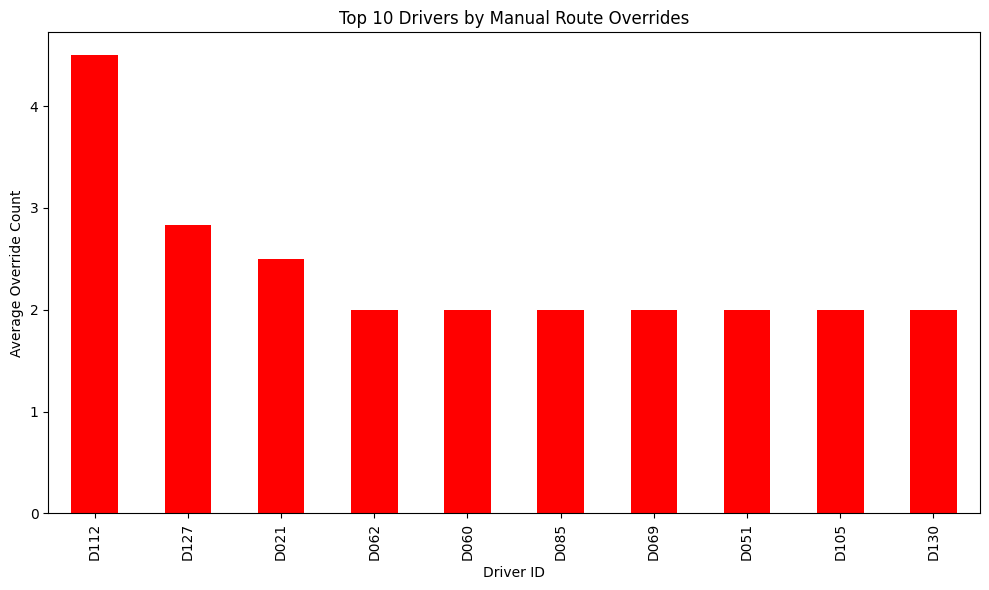

In [24]:
override_analysis.head(10).plot(kind="bar", figsize=(10,6), color="red")
plt.title("Top 10 Drivers by Manual Route Overrides")
plt.xlabel("Driver ID")
plt.ylabel("Average Override Count")
plt.tight_layout()
plt.show()

In [25]:
vehicle_incidents = deliveries.merge(incidents, on="delivery_id").merge(vehicles, on="vehicle_id")

maintenance_analysis = vehicle_incidents.groupby("maintenance_status")["incident_type"].value_counts().unstack()

print(maintenance_analysis)

incident_type       AppSyncError  BatteryAlert  CustomerNoShow  ProofMissing  \
maintenance_status                                                             
Active                        17            13              27            30   
InRepair                      12            18              11            11   
Scheduled                      2             5               6             5   

incident_type       RouteDeviation  SafetyNearMiss  TemperatureIssue  \
maintenance_status                                                     
Active                          24               7                12   
InRepair                         9               4                10   
Scheduled                       10               3                 7   

incident_type       VehicleFault  
maintenance_status                
Active                        20  
InRepair                       9  
Scheduled                      8  


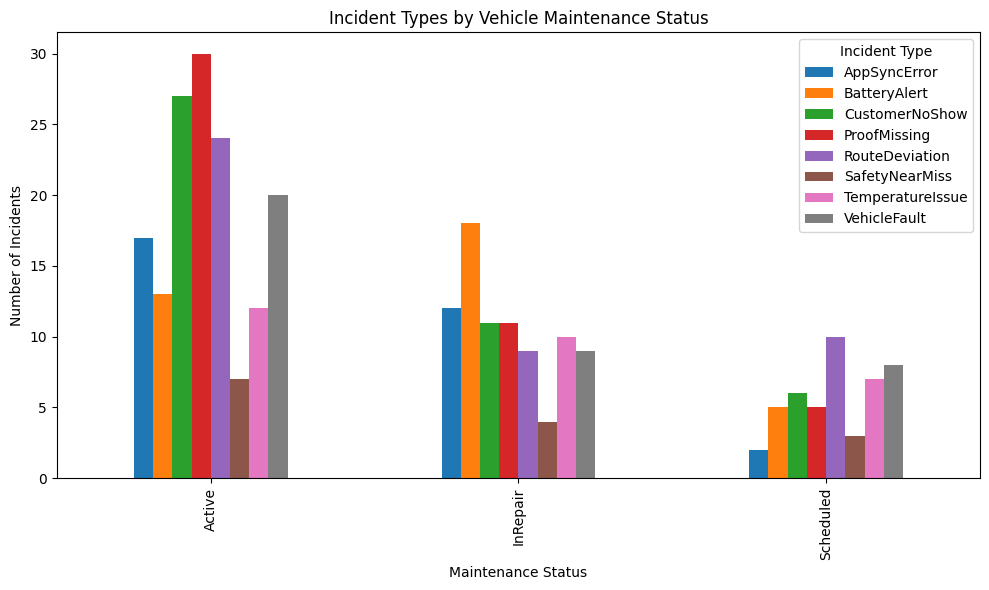

In [26]:
maintenance_analysis.plot(kind="bar", figsize=(10,6))
plt.title("Incident Types by Vehicle Maintenance Status")
plt.xlabel("Maintenance Status")
plt.ylabel("Number of Incidents")
plt.legend(title="Incident Type")
plt.tight_layout()
plt.show()

In [27]:
complaint_analysis = complaints.groupby("complaint_type")["complaint_id"].count().sort_values(ascending=False)

print(complaint_analysis)

complaint_type
Delay                101
MissedPickup          64
AppIssue              53
DriverBehaviour       51
SupportExperience     20
Billing               16
Damage                15
Name: complaint_id, dtype: int64


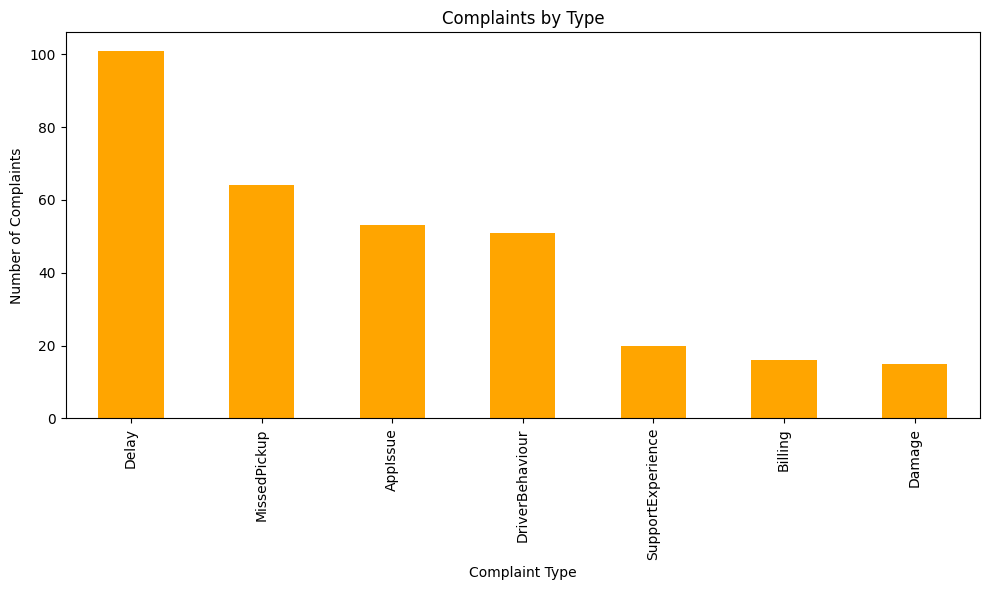

In [28]:
complaint_analysis.plot(kind="bar", figsize=(10,6), color="orange")
plt.title("Complaints by Type")
plt.xlabel("Complaint Type")
plt.ylabel("Number of Complaints")
plt.tight_layout()
plt.show()

In [29]:
profitability = deliveries.merge(orders, on="order_id")

profitability["profit"] = profitability["order_value"] - profitability["fuel_or_charge_cost"]

route_profit = profitability.groupby("pickup_zone")["profit"].mean().sort_values(ascending=False)

print(route_profit)

pickup_zone
Airport      84.640973
East         80.875000
South        79.890647
North        78.154741
Riverside    77.884958
West         77.113684
Central      75.704885
Name: profit, dtype: float64


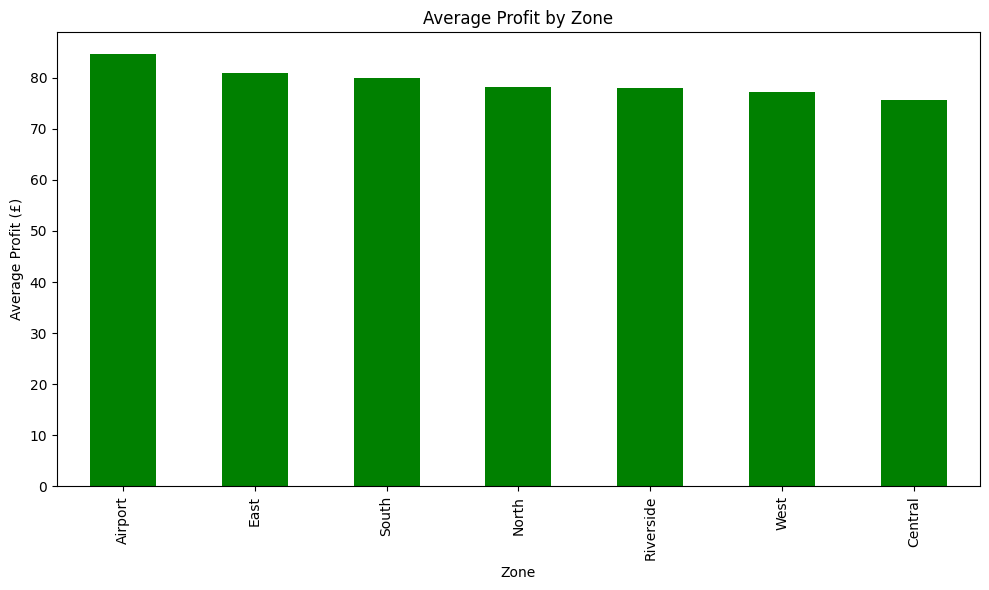

In [30]:
route_profit.plot(kind="bar", figsize=(10,6), color="green")
plt.title("Average Profit by Zone")
plt.xlabel("Zone")
plt.ylabel("Average Profit (£)")
plt.tight_layout()
plt.show()

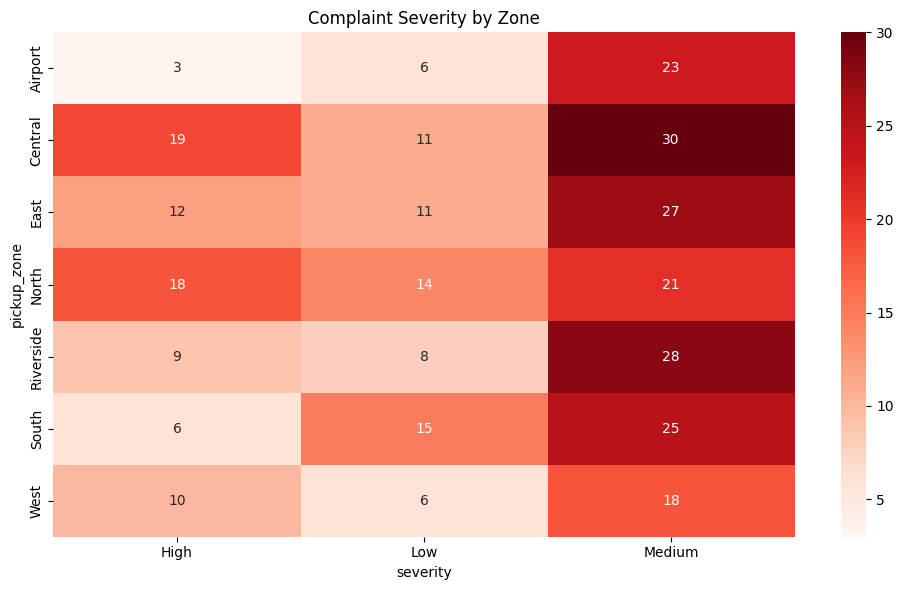

In [31]:
complaint_zone = complaints.merge(orders, on="order_id")

severity_zone = complaint_zone.groupby(["pickup_zone", "severity"])["complaint_id"].count().unstack()

plt.figure(figsize=(10,6))
sns.heatmap(severity_zone, annot=True, fmt="g", cmap="Reds")
plt.title("Complaint Severity by Zone")
plt.tight_layout()
plt.show()

In [7]:
# Save cleaned dataframes as new CSV files
customers.to_csv("customers_clean.csv", index=False)
drivers.to_csv("drivers_clean.csv", index=False)
vehicles.to_csv("vehicles_clean.csv", index=False)
orders.to_csv("orders_clean.csv", index=False)
deliveries.to_csv("deliveries_clean.csv", index=False)
complaints.to_csv("complaints_clean.csv", index=False)
incidents.to_csv("incidents_clean.csv", index=False)
hubs.to_csv("hubs_clean.csv", index=False)

print("Clean files saved!")

Clean files saved!
